### EDA

1. 데이터 출처, 주제
2. 데이터 사이즈
3. 데이터 속성, 특징 확인
- 위치추정 & 변이추정
- 수치 & 범주
- 속성간 상관관계 확인

피어슨 상관계수
heatmap차트, scatter차트

In [2]:
# EDA > HEATMAP

import pandas as pd
doc = pd.read_csv("COVID-19-master/csse_covid_19_data/csse_covid_19_daily_reports/04-01-2020.csv", encoding="utf-8-sig")

In [2]:
doc

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key
0,45001.0,Abbeville,South Carolina,US,2020-04-01 21:58:49,34.223334,-82.461707,4,0,0,4,"Abbeville, South Carolina, US"
1,22001.0,Acadia,Louisiana,US,2020-04-01 21:58:49,30.295065,-92.414197,47,1,0,46,"Acadia, Louisiana, US"
2,51001.0,Accomack,Virginia,US,2020-04-01 21:58:49,37.767072,-75.632346,7,0,0,7,"Accomack, Virginia, US"
3,16001.0,Ada,Idaho,US,2020-04-01 21:58:49,43.452658,-116.241552,195,3,0,192,"Ada, Idaho, US"
4,19001.0,Adair,Iowa,US,2020-04-01 21:58:49,41.330756,-94.471059,1,0,0,1,"Adair, Iowa, US"
...,...,...,...,...,...,...,...,...,...,...,...,...
2517,82604.0,NaN,Wales,United Kingdom,2020-04-01 21:58:49,52.130700,-3.783700,0,198,0,0,"Wales, United Kingdom"
2518,NaN,NaN,NaN,Nauru,2020-04-01 21:58:49,-0.522800,166.931500,0,0,0,0,Nauru
2519,NaN,NaN,Niue,New Zealand,2020-04-01 21:58:49,-19.054400,-169.867200,0,0,0,0,"Niue, New Zealand"
2520,NaN,NaN,NaN,Tuvalu,2020-04-01 21:58:49,-7.109500,177.649300,0,0,0,0,Tuvalu


In [3]:
doc2 = doc.corr(numeric_only=True) # correlation(상관관계) coefficient(계수)

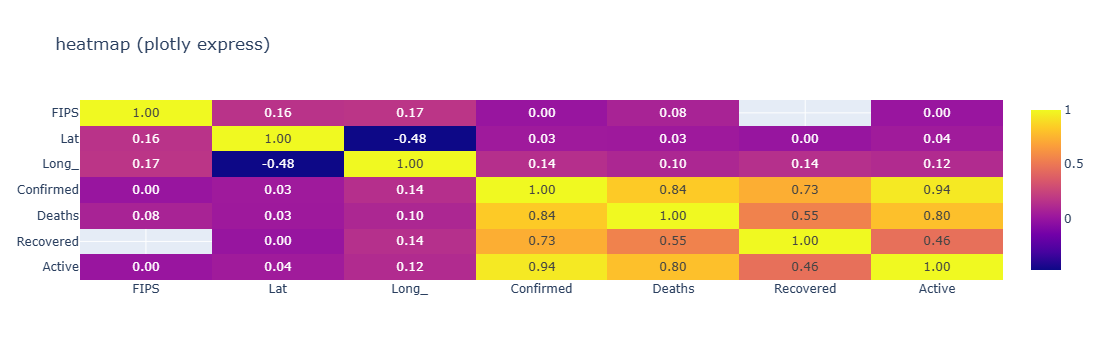

In [14]:
import plotly.express as px

fig_px = px.imshow(
    doc2,
    text_auto=".2f", #True, False, .nf
    aspect="auto", #auto : 텍스트 길이에 맞춰 칸의 크기 조절,  equal : 정해진 칸의 크기 사용
    title="heatmap (plotly express)"
    
)

fig_px.show()

In [4]:
doc2

,FIPS,Lat,Long_,Confirmed,Deaths,Recovered,Active
FIPS,1.000000,0.160717,0.171490,-0.000504,0.076467,NaN,0.002718
Lat,0.160717,1.000000,-0.476426,0.029389,0.026309,-0.002781,0.035631
Long_,0.171490,-0.476426,1.000000,0.141126,0.096924,0.141932,0.119737
Confirmed,-0.000504,0.029389,0.141126,1.000000,0.837153,0.727305,0.942484
Deaths,0.076467,0.026309,0.096924,0.837153,1.000000,0.546858,0.796549
Recovered,NaN,-0.002781,0.141932,0.727305,0.546858,1.000000,0.462484
Active,0.002718,0.035631,0.119737,0.942484,0.796549,0.462484,1.000000


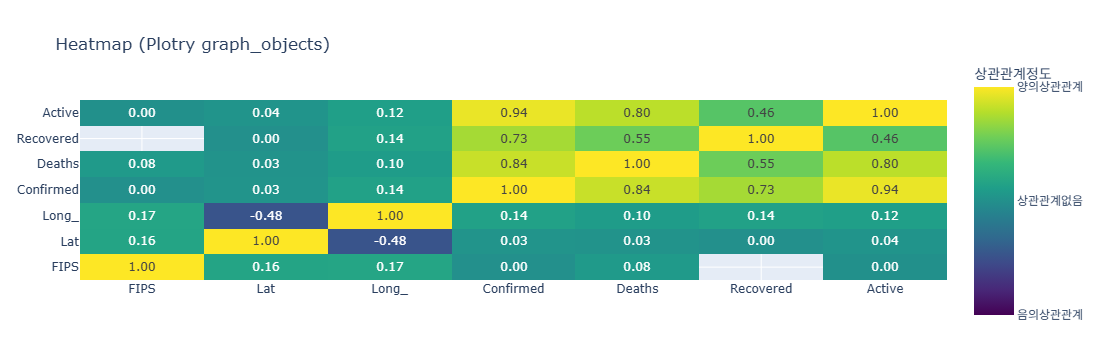

In [28]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Heatmap(
        x=doc2.columns,
        y=doc2.index,
        z=doc2.values,
        colorscale="Viridis", # Viridis : 라틴어로 그린이라는 뜻, Cividis, Plasma, Inferno, Magma, Rainbow, Jet, Picnic, Portland, Electric 등
        #colorscale=[(0, "red"), (0.5, "green"), (1, "#00f")], # 이런식으로도 컬러를 지절해서 쓸 수 있다
        colorbar={
            "title": "상관관계정도",
            "thickness": 40,
            "tickvals":[-1, 0, 1],
            "ticktext":["음의상관관계", "상관관계없음", "양의상관관계"],
            "len": 1.5
        },
        zmin=-1,
        zmax=1,
        text=doc2.values, 
        texttemplate="%{z:.2f}",
        hovertemplate="X: %{x}<br>Y: %{y}<br>Value: %{z:.2f}<extra>Custom Info</extra>" 
    )
)
fig.update_layout(title="Heatmap (Plotry graph_objects)")
fig.show()

# X: %{x} : 마우스 오버 했을때 x 값 나옴
# <br> : 개행처리
# Y: %{y} : 마우스 오버 했을때 y 값 나옴
# Value: %{z:.2f} : 마우스 오버 했을때 값 나옴

In [29]:
# EDA > SCATTER

import pandas as pd
doc = pd.read_csv("COVID-19-master/csse_covid_19_data/csse_covid_19_daily_reports/04-01-2020.csv", encoding="utf-8-sig")

In [30]:
doc

,FIPS,Admin2,Province_State,Country_Region,Last_Update,Lat,Long_,Confirmed,Deaths,Recovered,Active,Combined_Key
0,45001.0,Abbeville,South Carolina,US,2020-04-01 21:58:49,34.223334,-82.461707,4,0,0,4,"Abbeville, South Carolina, US"
1,22001.0,Acadia,Louisiana,US,2020-04-01 21:58:49,30.295065,-92.414197,47,1,0,46,"Acadia, Louisiana, US"
2,51001.0,Accomack,Virginia,US,2020-04-01 21:58:49,37.767072,-75.632346,7,0,0,7,"Accomack, Virginia, US"
3,16001.0,Ada,Idaho,US,2020-04-01 21:58:49,43.452658,-116.241552,195,3,0,192,"Ada, Idaho, US"
4,19001.0,Adair,Iowa,US,2020-04-01 21:58:49,41.330756,-94.471059,1,0,0,1,"Adair, Iowa, US"
...,...,...,...,...,...,...,...,...,...,...,...,...
2517,82604.0,NaN,Wales,United Kingdom,2020-04-01 21:58:49,52.130700,-3.783700,0,198,0,0,"Wales, United Kingdom"
2518,NaN,NaN,NaN,Nauru,2020-04-01 21:58:49,-0.522800,166.931500,0,0,0,0,Nauru
2519,NaN,NaN,Niue,New Zealand,2020-04-01 21:58:49,-19.054400,-169.867200,0,0,0,0,"Niue, New Zealand"
2520,NaN,NaN,NaN,Tuvalu,2020-04-01 21:58:49,-7.109500,177.649300,0,0,0,0,Tuvalu


In [31]:
doc.corr(numeric_only=True)

,FIPS,Lat,Long_,Confirmed,Deaths,Recovered,Active
FIPS,1.000000,0.160717,0.171490,-0.000504,0.076467,NaN,0.002718
Lat,0.160717,1.000000,-0.476426,0.029389,0.026309,-0.002781,0.035631
Long_,0.171490,-0.476426,1.000000,0.141126,0.096924,0.141932,0.119737
Confirmed,-0.000504,0.029389,0.141126,1.000000,0.837153,0.727305,0.942484
Deaths,0.076467,0.026309,0.096924,0.837153,1.000000,0.546858,0.796549
Recovered,NaN,-0.002781,0.141932,0.727305,0.546858,1.000000,0.462484
Active,0.002718,0.035631,0.119737,0.942484,0.796549,0.462484,1.000000


In [32]:
import plotly.io as pio

pio.templates

Templates configuration
-----------------------
    Default template: 'plotly'
    Available templates:
        ['ggplot2', 'seaborn', 'simple_white', 'plotly',
         'plotly_white', 'plotly_dark', 'presentation', 'xgridoff',
         'ygridoff', 'gridon', 'none']

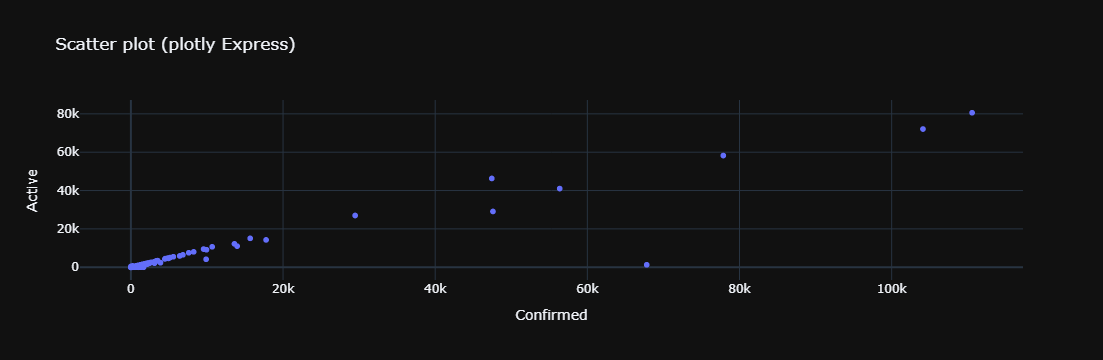

In [35]:
import plotly.express as px

fig_px = px.scatter(
    doc,
    x="Confirmed",
    y="Active",
    title="Scatter plot (plotly Express)"
)

fig_px.update_layout(template="plotly_dark")

fig_px.show()

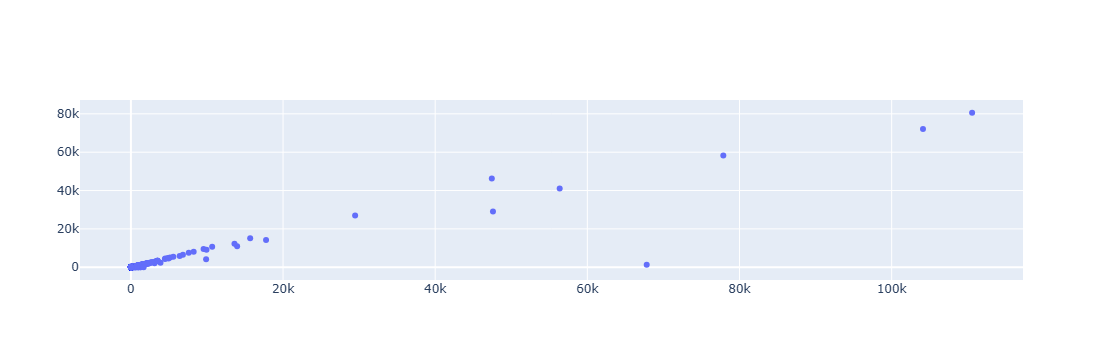

In [37]:
import plotly.graph_objects as go

fig = go.Figure()

fig.add_trace(
    go.Scatter(
        x=doc["Confirmed"],
        y=doc["Active"],
        mode="markers"
    )
)

fig.show()